In [6]:
!pip install gensim
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

import pickle

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:

!pip install nlpaug
import nlpaug.augmenter.word as naw

aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.3) 

In [8]:
import os

DATASET_PATH = "IMDB Dataset.csv"

RESULT_PATH = "results"

W2V_PATH = os.path.join(RESULT_PATH, "word2vec")
CNN_PATH = os.path.join(RESULT_PATH, "cnn_model")
EVAL_PATH = os.path.join(RESULT_PATH, "evaluation")

os.makedirs(W2V_PATH, exist_ok=True)
os.makedirs(CNN_PATH, exist_ok=True)
os.makedirs(EVAL_PATH, exist_ok=True)

print("Path siap")

Path siap


In [9]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
print("Downloaded 'averaged_perceptron_tagger_eng'")

Downloaded 'averaged_perceptron_tagger_eng'


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [10]:
df = pd.read_csv(DATASET_PATH)

print(df.head())
print(df["sentiment"].value_counts())


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [11]:
import nltk
nltk.download('punkt_tab')

import re

stop_words = set(stopwords.words("english"))

def preprocess(text):
    # Hapus tag HTML
    text = re.sub(r'<.*?>', ' ', text)
    # Hapus tanda baca dan angka
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)
    text = text.lower()
    # Tokenisasi
    tokens = word_tokenize(text)
    # Hapus stopwords dan kata pendek (kurang dari 2 huruf)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df["tokens"] = df["review"].apply(preprocess)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,review,sentiment,tokens
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, episode,..."
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,"[basically, family, little, boy, jake, thinks,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, mattei, love, time, money, visually, ..."


In [12]:
augmented_reviews = []
augmented_sentiments = []


df_original = pd.read_csv(DATASET_PATH)
df_original["tokens"] = df_original["review"].apply(preprocess)

for index, row in df_original.iterrows():
    original_review = row['review']
    original_sentiment = row['sentiment']

    augmented_review = aug.augment(original_review)[0]

    augmented_reviews.append(augmented_review)
    augmented_sentiments.append(original_sentiment)

df_augmented = pd.DataFrame({
    'review': augmented_reviews,
    'sentiment': augmented_sentiments
})

df = pd.concat([df_original, df_augmented], ignore_index=True)

print(f"Original DataFrame shape: {len(df_original)}")
print(f"Augmented DataFrame shape: {len(df_augmented)}")
print(f"New combined DataFrame shape: {df.shape}")
print(df["sentiment"].value_counts())

Original DataFrame shape: 50000
Augmented DataFrame shape: 50000
New combined DataFrame shape: (100000, 3)
sentiment
positive    50000
negative    50000
Name: count, dtype: int64


In [14]:
GENRE_KEYWORDS = {
    "Action": [
        "fight", "battle", "war", "gun", "weapon", "explosion", "shoot",
        "chase", "army", "soldier", "attack", "combat"
    ],
    "Romance": [
        "love", "romantic", "couple", "relationship", "kiss", "marriage",
        "heart", "emotion", "passion", "dating"
    ],
    "Horror": [
        "horror", "ghost", "dead", "death", "blood", "kill", "murder",
        "monster", "evil", "scary", "fear", "nightmare", "haunted"
    ],
    "Comedy": [
        "funny", "laugh", "joke", "humor", "hilarious", "ridiculous",
        "parody", "satire", "comedy"
    ]
}

def assign_genre(tokens):
    text = " ".join(tokens)
    for genre, keywords in GENRE_KEYWORDS.items():
        if any(word in text for word in keywords):
            return genre
    return "Drama"

df["genre"] = df["tokens"].apply(assign_genre)

print(df["genre"].value_counts())

genre
Action     39662
Romance    22212
Drama      17768
Horror     11948
Comedy      8410
Name: count, dtype: int64


In [15]:
sentences = df["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=7,
    min_count=3,
    workers=4,
    sg=1,
    epochs=20
)

w2v_model.save(os.path.join(W2V_PATH, "word2vec.model"))
print("Word2Vec saved")

Word2Vec saved


In [16]:
texts = df["tokens"].apply(lambda x: " ".join(x))

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

MAX_LEN = 200
X = pad_sequences(sequences, maxlen=MAX_LEN)

y = df["sentiment"].map({"positive": 1, "negative": 0}).values
y = to_categorical(y, 2)

print(X.shape, y.shape)


(100000, 200) (100000, 2)


In [17]:
word_index = tokenizer.word_index
VOCAB_SIZE = len(word_index) + 1
EMBEDDING_DIM = 200

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for word, idx in word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),

    Conv1D(128, 5, activation='relu'),
    Dropout(0.3),
    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    20,602,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,602,400 (78.59 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,602,400 (78.59 MB)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-5)
]

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.7726 - loss: 0.4410 - val_accuracy: 0.8829 - val_loss: 0.2838 - learning_rate: 0.0010
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8900 - loss: 0.2716 - val_accuracy: 0.9034 - val_loss: 0.2682 - learning_rate: 0.0010
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9108 - loss: 0.2270 - val_accuracy: 0.9103 - val_loss: 0.2293 - learning_rate: 0.0010
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9293 - loss: 0.1838 - val_accuracy: 0.9022 - val_loss: 0.2374 - learning_rate: 0.0010
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9379 - loss: 0.1613 - val_accuracy: 0.9311 - val_loss: 0.1810 - learning_rate: 0.0010
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9518 - loss: 0.1301 - val_accuracy: 0.9400 - val_loss: 0.1707 - learning_rate: 0.0010
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9590 -

In [22]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

report = classification_report(y_true, y_pred)
print(report)

with open(os.path.join(EVAL_PATH, "classification_report_augmented.txt"), "w") as f:
    f.write(report)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9478 - loss: 0.1519
Test Accuracy: 0.9476500153541565
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10000
           1       0.95      0.95      0.95     10000

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



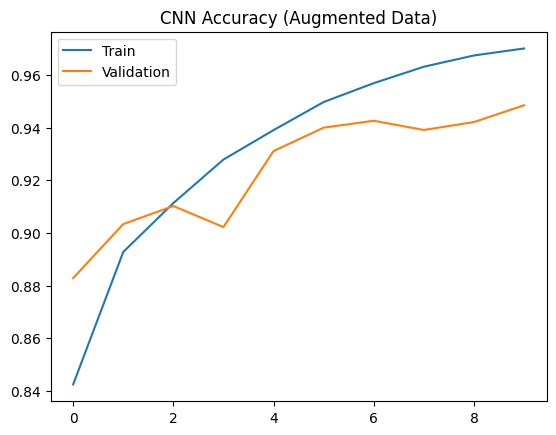

In [23]:
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.legend()
plt.title("CNN Accuracy (Augmented Data)")
plt.savefig(os.path.join(EVAL_PATH, "accuracy_augmented.png"))
plt.show()

In [ ]:
model.save(os.path.join(CNN_PATH, "cnn_sentiment_model.h5"))

with open(os.path.join(CNN_PATH, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)


In [26]:
def predict_review(text):
    tokens = preprocess(text)

    # Sentiment
    seq = tokenizer.texts_to_sequences([" ".join(tokens)])
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    sentiment = np.argmax(model.predict(pad), axis=1)[0]
    sentiment = "Positive" if sentiment == 1 else "Negative"

    # Genre
    genre = assign_genre(tokens)

    return sentiment, genre


review = "The horror elements were disappointing and not scary at all"
sent, gen = predict_review(review)

print("Review:", review)
print("Sentiment:", sent)
print("Predicted Genre:", gen)

review_2 = "This action-packed movie with intense fight scenes and explosions was thrilling!"
sent_2, gen_2 = predict_review(review_2)

print("\nReview:", review_2)
print("Sentiment:", sent_2)
print("Predicted Genre:", gen_2)

review_3 = "A wonderfully romantic tale of love and passion that captured my heart."
sent_3, gen_3 = predict_review(review_3)

print("\nReview:", review_3)
print("Sentiment:", sent_3)
print("Predicted Genre:", gen_3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step
Review: The horror elements were disappointing and not scary at all
Sentiment: Positive
Predicted Genre: Horror
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Review: This action-packed movie with intense fight scenes and explosions was thrilling!
Sentiment: Positive
Predicted Genre: Action
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Review: A wonderfully romantic tale of love and passion that captured my heart.
Sentiment: Positive
Predicted Genre: Romance
